<a href="https://www.kaggle.com/code/lalit7881/space-missions-analytics-1957-2035-eda?scriptVersionId=317527167" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maulikgajera/global-space-missions-dataset-19502025/Space_Missions_Dataset.csv
/kaggle/input/datasets/maulikgajera/global-space-missions-dataset-19502025/README_Space_Missions_Dataset.md


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/maulikgajera/global-space-missions-dataset-19502025/Space_Missions_Dataset.csv")

In [3]:
df.head()

,Mission_ID,Mission_Name,Agency,Country_Region,Agency_Type,Program_Type,Mission_Category,Sub_Category,Launch_Date,End_Date,...,Crew_Members,Destination,Objective,Key_Achievement,Cost_USD_Million,Partner_Agencies,Data_Returned,Failure_Reason,Mission_Outcome_Detail,Reference_URL
0,NA-00001,Explorer 1,NASA,USA,Government,Technology Demo,Mercury,Orbiter,1976-01-12,1987-02-18,...,NaN,Mercury,Black hole imaging and stellar cataloguing,Debris impact damaged solar panels,7708.6,NaN,Partial,Debris impact damaged solar panels,Exceeded planned science return by 3x,https://www.nasa.gov/mission/explorer-1
1,NA-00002,Pioneer 1,NASA,USA,Government,Human Spaceflight,Saturn,Flyby,1977-05-01,1984-07-15,...,NaN,Saturn,Orbital mechanics experiment for future missions,Detected water ice at target location,11802.2,SpaceX,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/pioneer-1
2,NA-00003,Mercury-Redstone 1,NASA,USA,Government,Sounding Rocket,Earth Observation,Climate Study,1966-01-13,1969-12-13,...,"Pilot, PS2",Earth Observation,Gamma-ray burst detection and cataloguing,NaN,7836.7,NaN,Yes,NaN,Planned - objectives to be confirmed post-launch,https://www.nasa.gov/mission/mercury-redstone-1
3,NA-00004,Freedom 7,NASA,USA,Government,Satellite,Mercury,Flyby,1987-07-06,1989-03-19,...,NaN,Mercury,Earth observation for disaster management,Demonstrated reusable rocket landing,10659.5,NaN,Partial,NaN,Failed to achieve orbit due to launch vehicle ...,https://www.nasa.gov/mission/freedom-7
4,NA-00005,Friendship 7,NASA,USA,Government,Commercial,Telescope,Radio,2012-09-09,NaN,...,NaN,Telescope,Human lunar landing mission support,Discovered new geological features,4385.5,JAXA,Yes,NaN,Detected organic molecules at surface,https://www.nasa.gov/mission/friendship-7


In [4]:
df.tail()

,Mission_ID,Mission_Name,Agency,Country_Region,Agency_Type,Program_Type,Mission_Category,Sub_Category,Launch_Date,End_Date,...,Crew_Members,Destination,Objective,Key_Achievement,Cost_USD_Million,Partner_Agencies,Data_Returned,Failure_Reason,Mission_Outcome_Detail,Reference_URL
10495,CS-10496,CSA CubeSat Mission 10496,CSA,Canada,Government,Human Spaceflight,CubeSat,12U CubeSat,2026-01-12,NaN,...,NaN,CubeSat,Heliosphere boundary exploration,Communication lost after initial deployment,6742.1,NaN,No,NaN,Partial success - secondary objectives met,https://www.asc-csa.gc.ca/mission/csa-cubesat-...
10496,CN-10497,CNES Asteroid Mission 10497,CNES,France,Government,Commercial,Asteroid,Sample Return,2012-12-31,2020-06-29,...,NaN,Asteroid,Mars atmospheric study and habitability assess...,Discovered new geological features,4133.8,ISRO,No,NaN,Achieved supersonic retropropulsion,https://cnes.fr/mission/cnes-asteroid-mission-...
10497,CN-10498,CNSA Venus Mission 10498,CNSA,China,Government,Satellite,Venus,Atmospheric Probe,1988-10-17,1991-03-09,...,NaN,Venus,Commercial crew certification flight,Collected and returned surface samples,14362.9,NaN,No,NaN,Confirmed presence of subsurface water,http://www.cnsa.gov.cn/mission/cnsa-venus-miss...
10498,CN-10499,CNSA Deep Space Mission 10499,CNSA,China,Government,Human Spaceflight,Deep Space,Voyager-type,1978-08-16,1982-05-26,...,NaN,Deep Space,Next-generation communication satellite deploy...,First images returned from target destination,11086.1,NaN,Yes,NaN,Mission ongoing - data collection in progress,http://www.cnsa.gov.cn/mission/cnsa-deep-space...
10499,CN-10500,CNSA Sun/Solar Mission 10500,CNSA,China,Government,Sounding Rocket,Sun/Solar,Coronagraph,2023-02-26,NaN,...,NaN,Sun/Solar,Earth climate monitoring and greenhouse gas me...,Detected water ice at target location,6533.7,NaN,Yes,NaN,Successfully tested new propulsion system,http://www.cnsa.gov.cn/mission/cnsa-sun/solar-...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mission_ID              10500 non-null  object 
 1   Mission_Name            10500 non-null  object 
 2   Agency                  10500 non-null  object 
 3   Country_Region          10500 non-null  object 
 4   Agency_Type             10500 non-null  object 
 5   Program_Type            10500 non-null  object 
 6   Mission_Category        10500 non-null  object 
 7   Sub_Category            10500 non-null  object 
 8   Launch_Date             10500 non-null  object 
 9   End_Date                5796 non-null   object 
 10  Duration                10266 non-null  object 
 11  Launch_Vehicle          10500 non-null  object 
 12  Launch_Site             10500 non-null  object 
 13  Status                  10500 non-null  object 
 14  Mission_Phase           10500 non-null

In [6]:
df.describe()

,Cost_USD_Million
count,10500.000000
mean,7383.777229
std,4314.648281
min,5.100000
25%,3662.100000
50%,7398.300000
75%,11064.025000
max,14998.500000


In [7]:
df.columns

Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL'],
      dtype='object')

In [8]:
df.isnull().sum()

Mission_ID                   0
Mission_Name                 0
Agency                       0
Country_Region               0
Agency_Type                  0
Program_Type                 0
Mission_Category             0
Sub_Category                 0
Launch_Date                  0
End_Date                  4704
Duration                   234
Launch_Vehicle               0
Launch_Site                  0
Status                       0
Mission_Phase                0
Crew_Type                    0
Crew_Members              7863
Destination                  0
Objective                    0
Key_Achievement            321
Cost_USD_Million             0
Partner_Agencies          6164
Data_Returned             1560
Failure_Reason            9339
Mission_Outcome_Detail       0
Reference_URL                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Mission_ID                 object
Mission_Name               object
Agency                     object
Country_Region             object
Agency_Type                object
Program_Type               object
Mission_Category           object
Sub_Category               object
Launch_Date                object
End_Date                   object
Duration                   object
Launch_Vehicle             object
Launch_Site                object
Status                     object
Mission_Phase              object
Crew_Type                  object
Crew_Members               object
Destination                object
Objective                  object
Key_Achievement            object
Cost_USD_Million          float64
Partner_Agencies           object
Data_Returned              object
Failure_Reason             object
Mission_Outcome_Detail     object
Reference_URL              object
dtype: object

In [11]:
df.shape

(10500, 26)

In [12]:
df.nunique()

Mission_ID                10500
Mission_Name              10477
Agency                       27
Country_Region               10
Agency_Type                   2
Program_Type                  7
Mission_Category             19
Sub_Category                 66
Launch_Date                8496
End_Date                   5067
Duration                    421
Launch_Vehicle               44
Launch_Site                  26
Status                        5
Mission_Phase                 3
Crew_Type                     2
Crew_Members               1792
Destination                  19
Objective                    25
Key_Achievement              34
Cost_USD_Million          10151
Partner_Agencies             10
Data_Returned                 3
Failure_Reason               12
Mission_Outcome_Detail       25
Reference_URL             10497
dtype: int64

## EDA

DATASET SHAPE
(10500, 26)

COLUMN NAMES
Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL'],
      dtype='object')

FIRST 5 ROWS
  Mission_ID        Mission_Name Agency Country_Region Agency_Type  \
0   NA-00001          Explorer 1   NASA            USA  Government   
1   NA-00002           Pioneer 1   NASA            USA  Government   
2   NA-00003  Mercury-Redstone 1   NASA            USA  Government   
3   NA-00004           Freedom 7   NASA            USA  Government   
4   NA-00005        Friendship 7   NASA            USA  Government   

        Program_Type   Mission_Cate

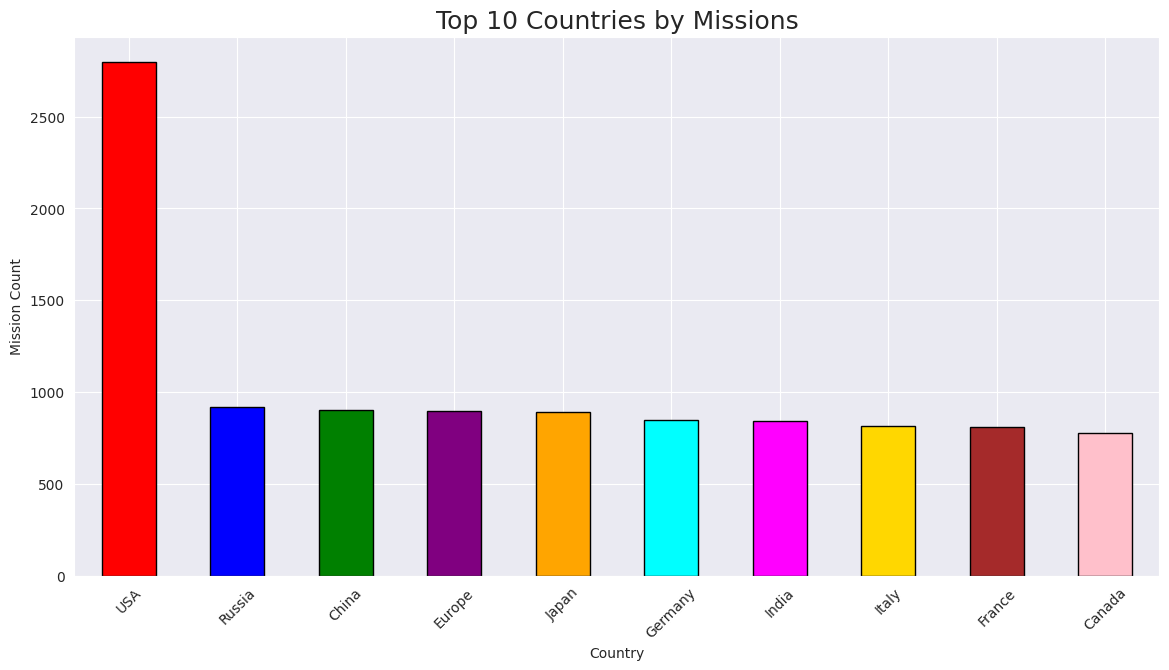

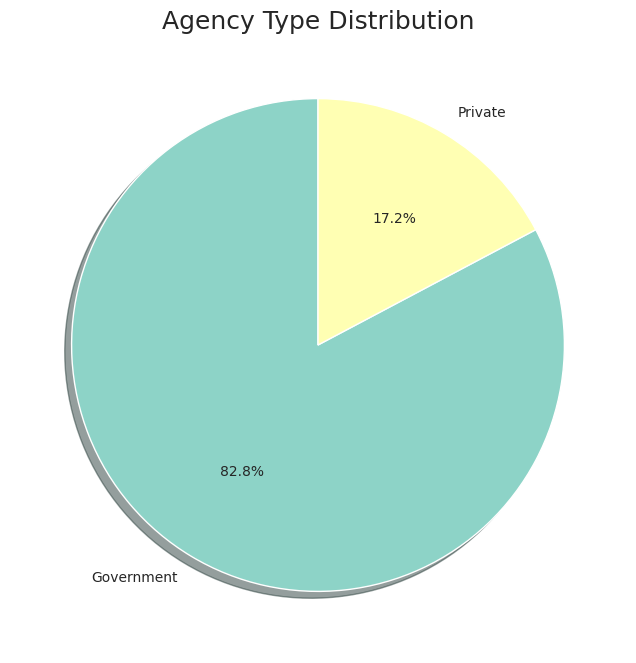

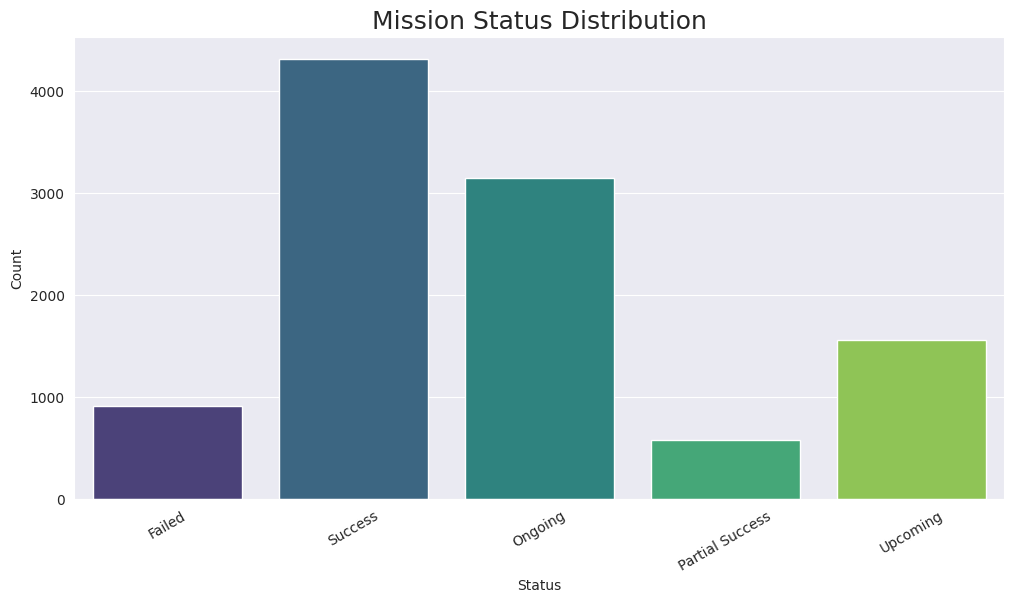

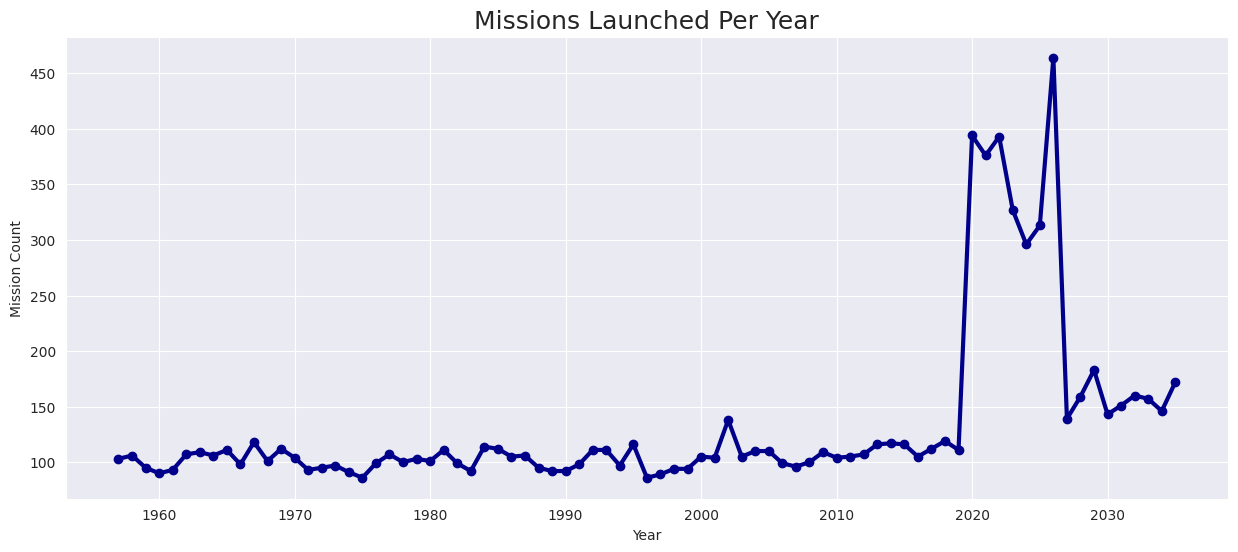

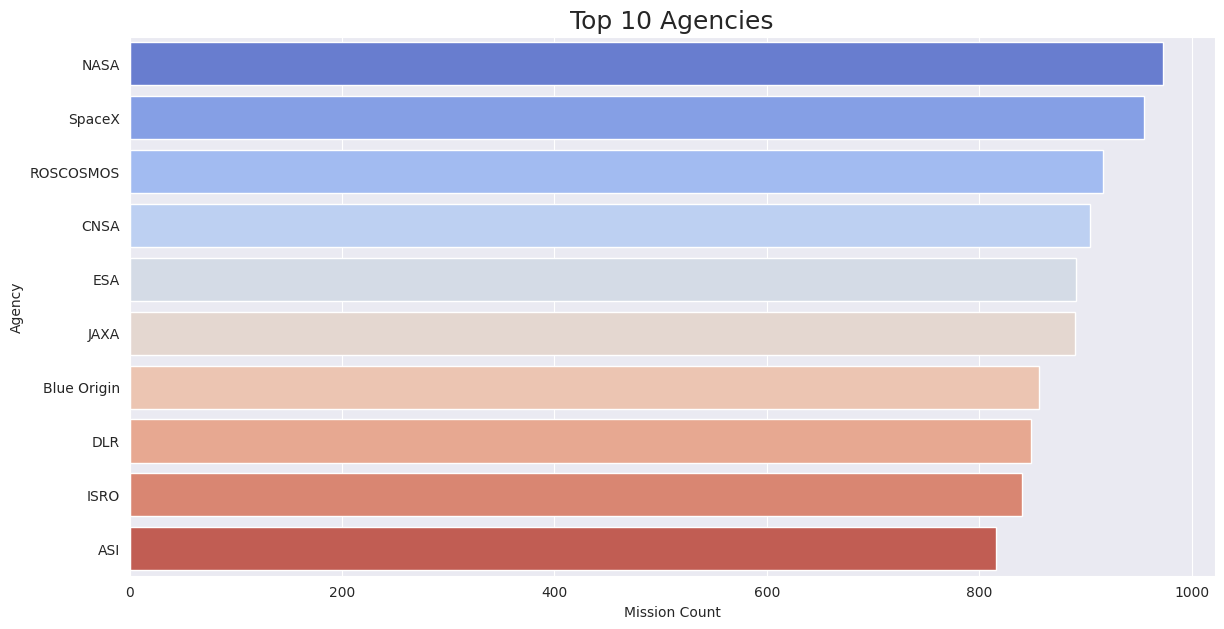

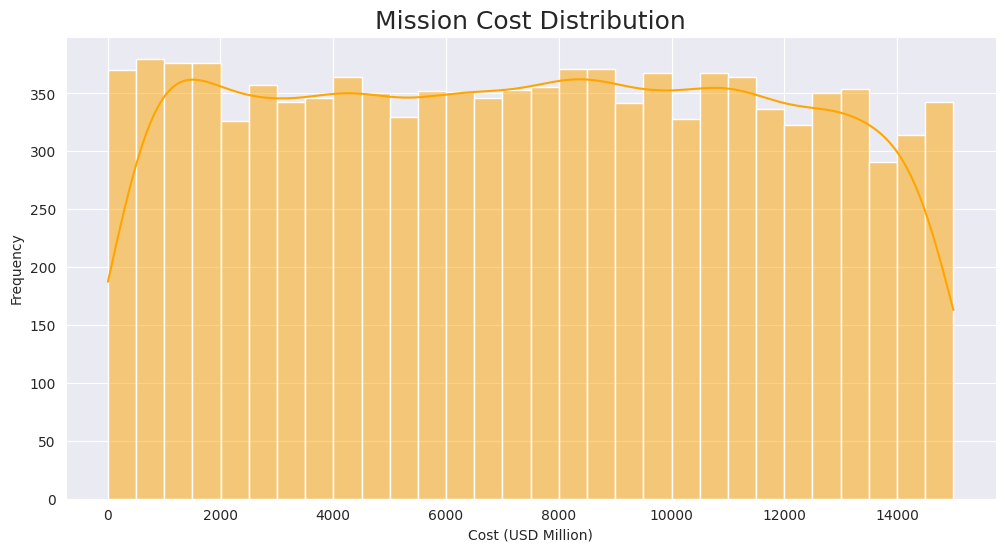

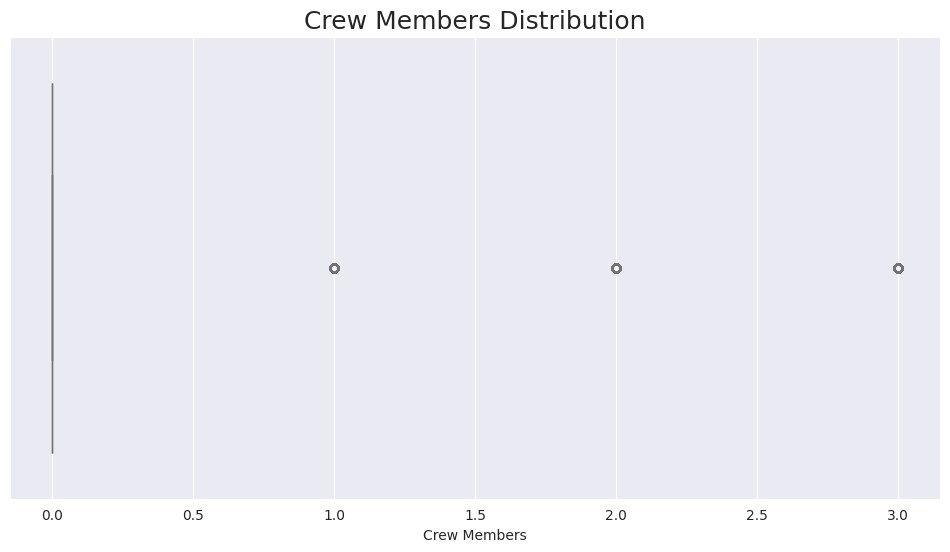

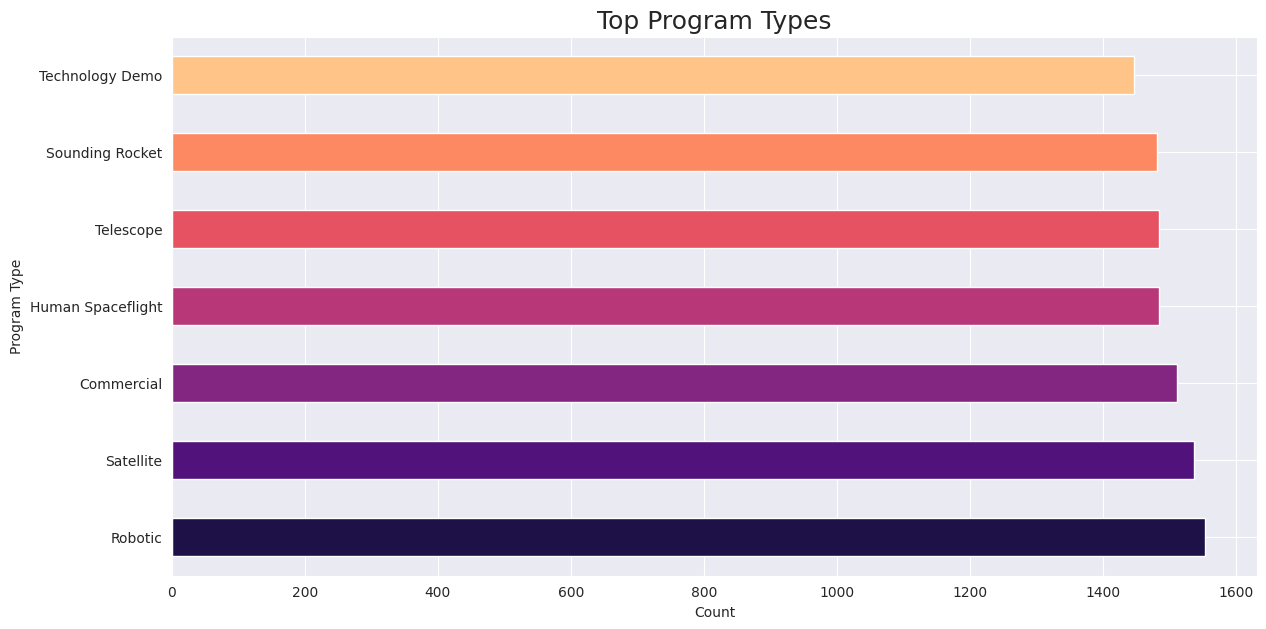

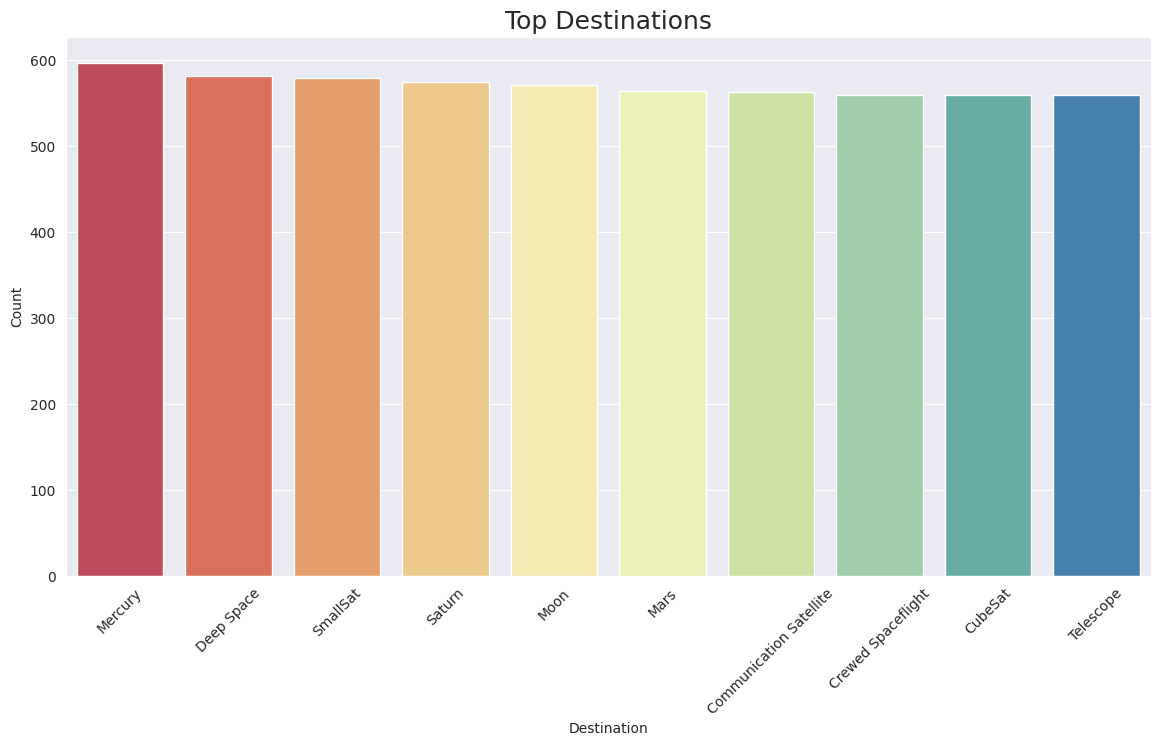

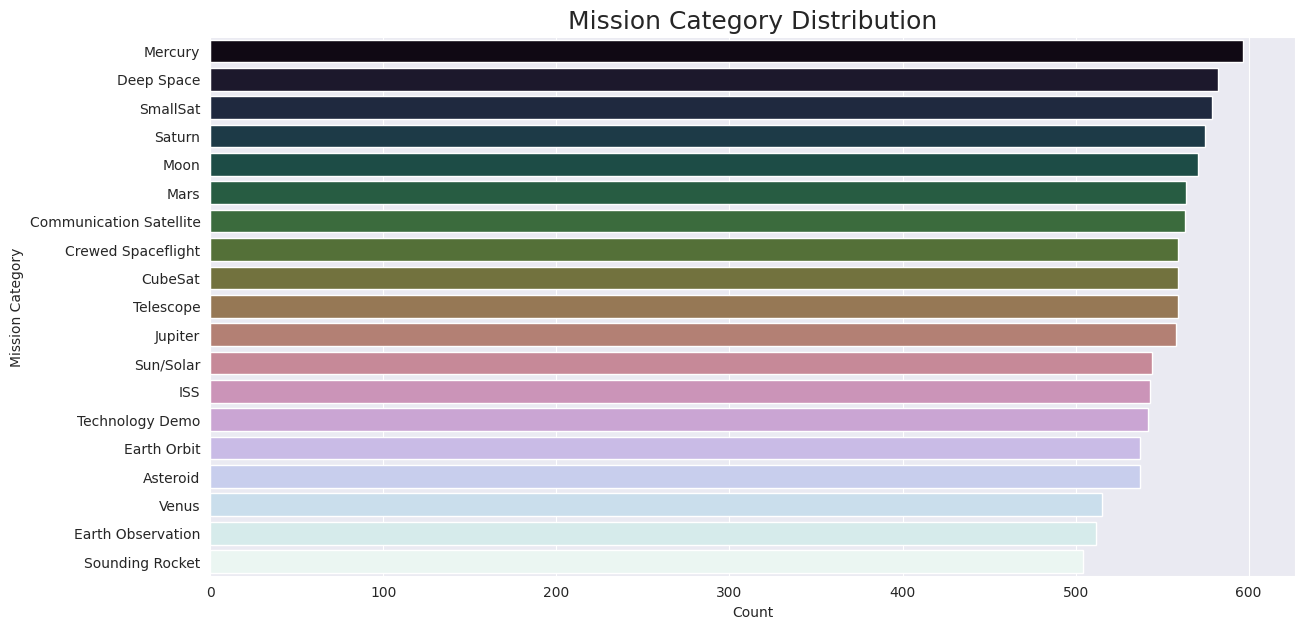

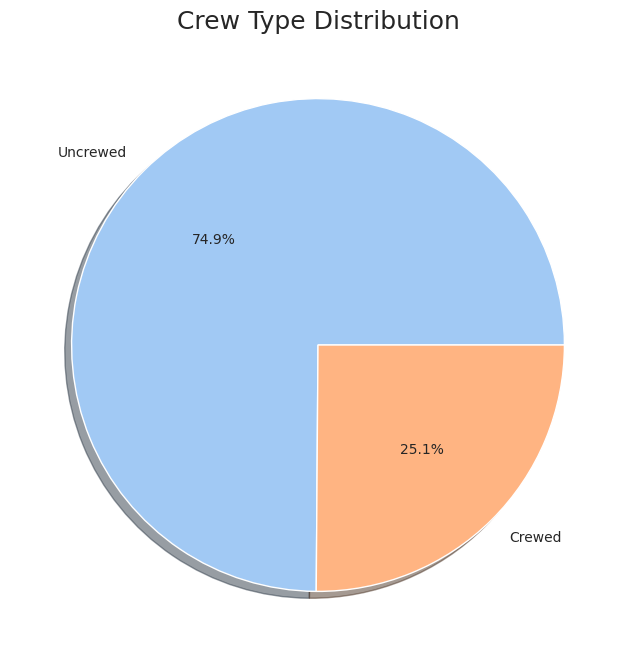

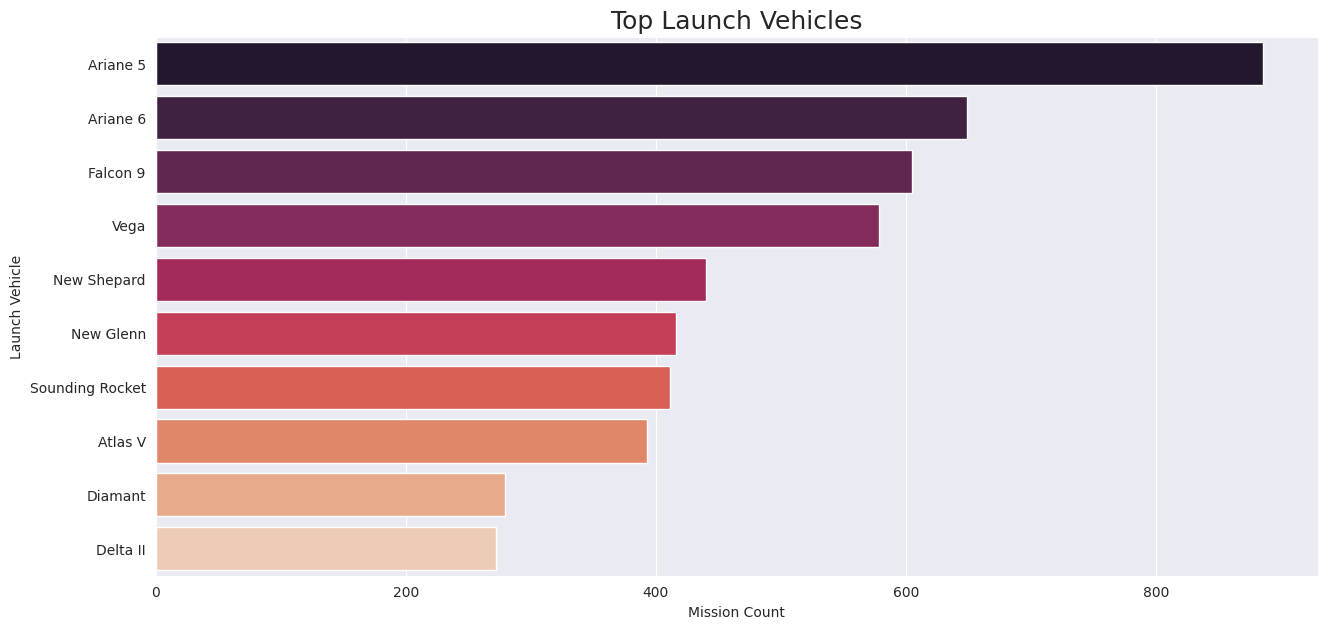

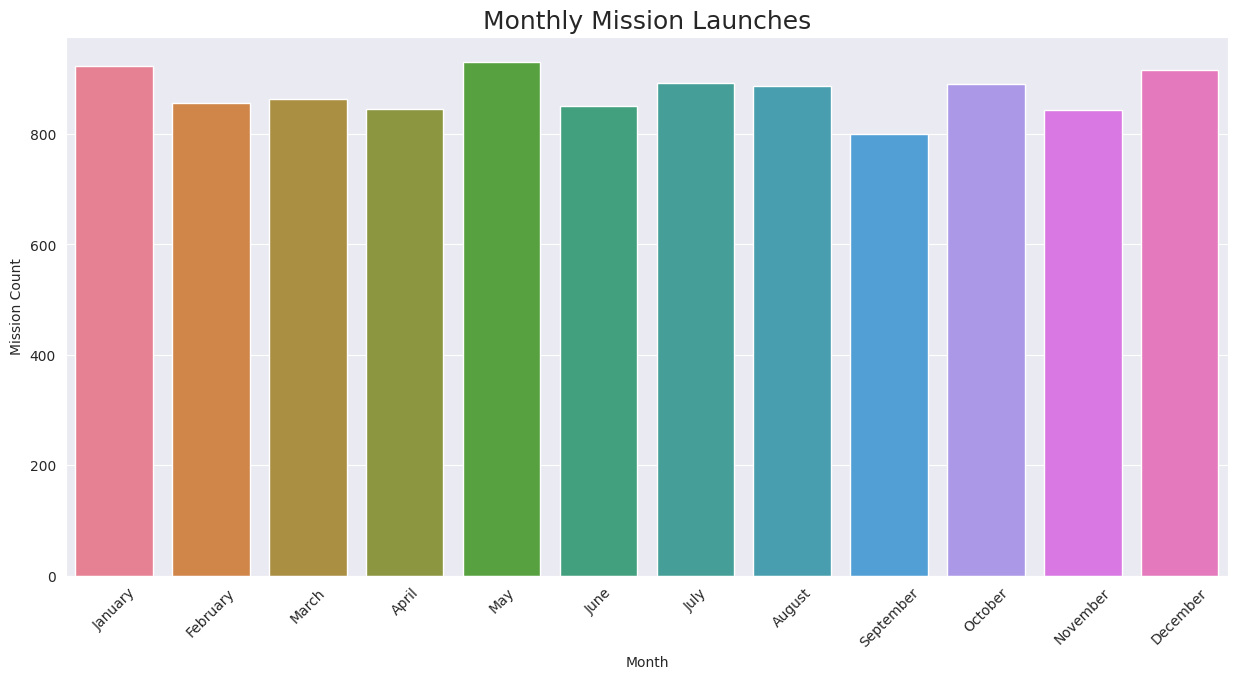

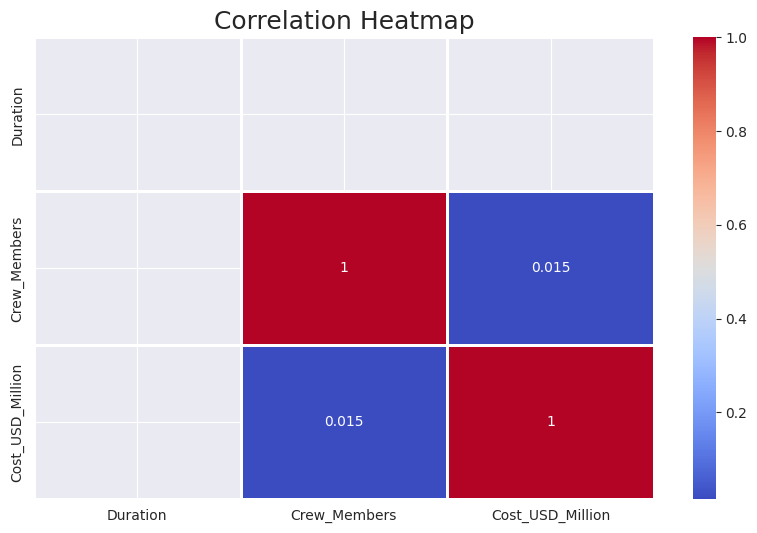

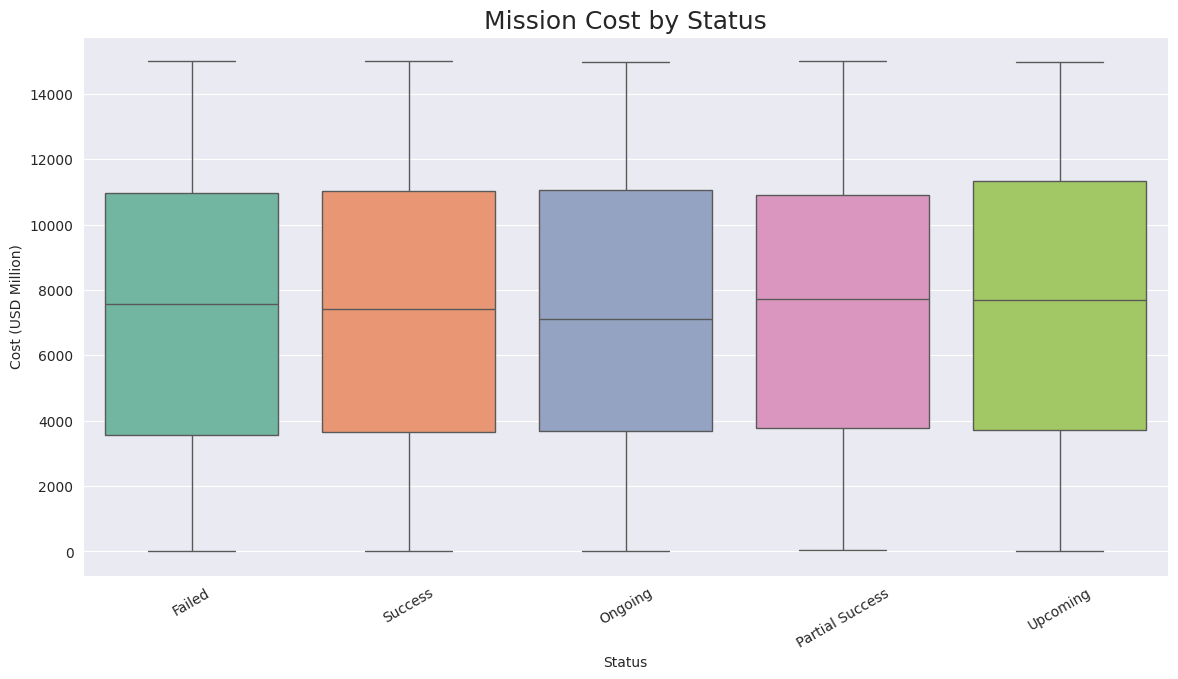

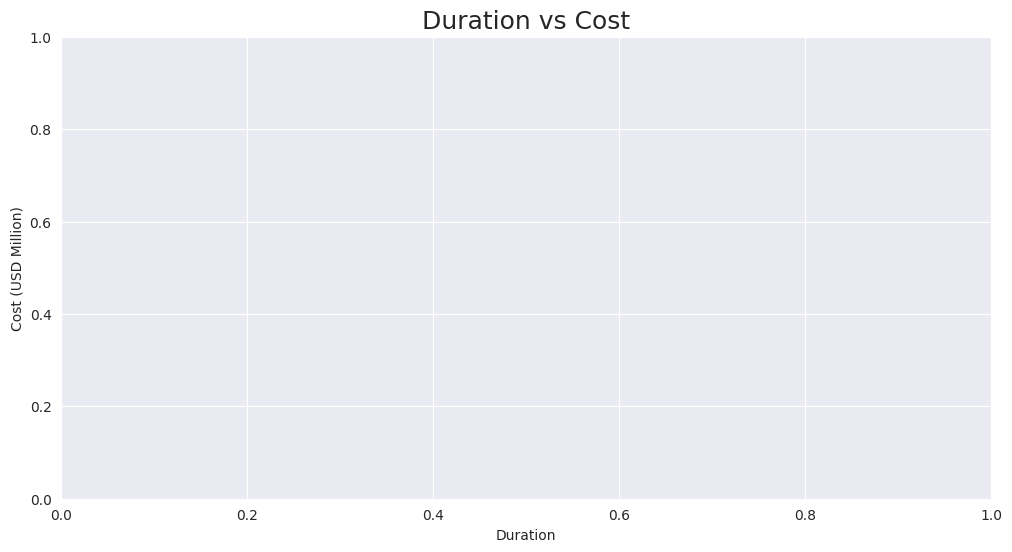

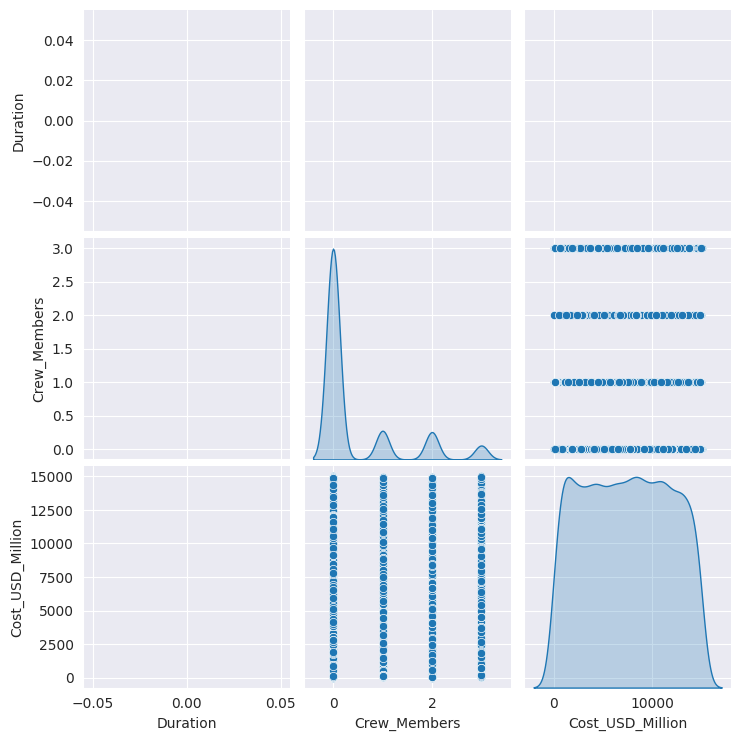

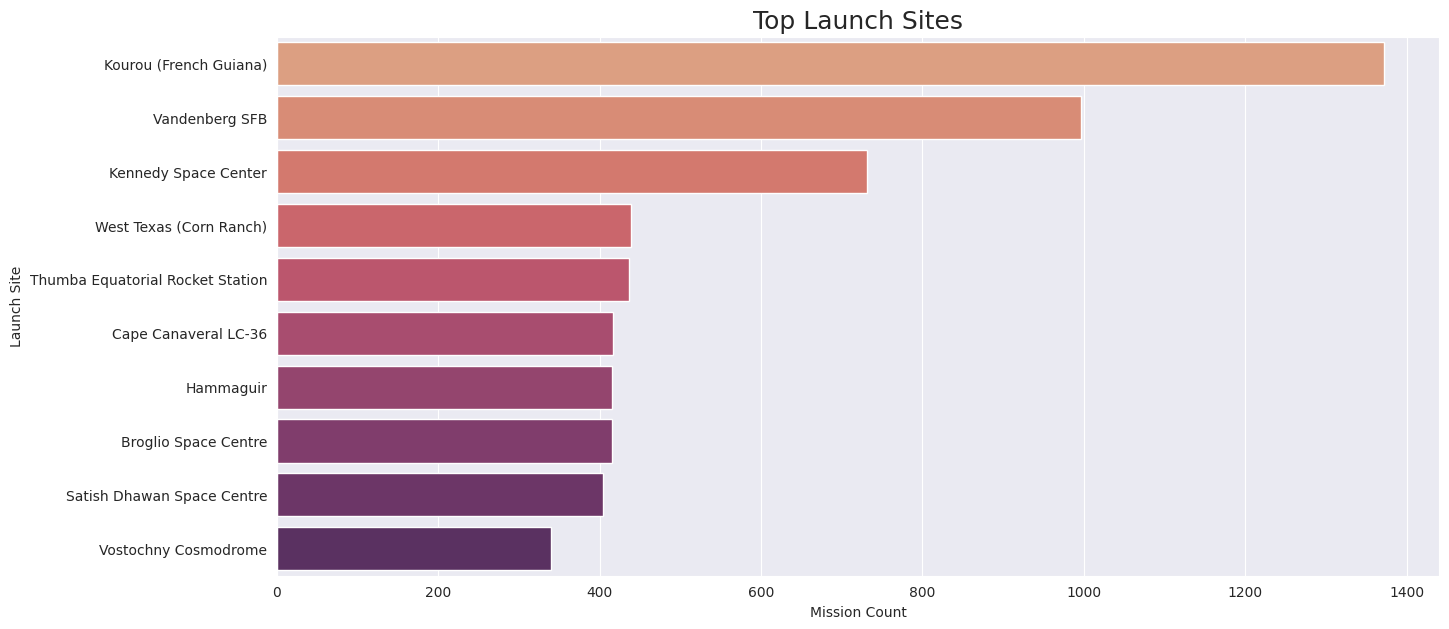

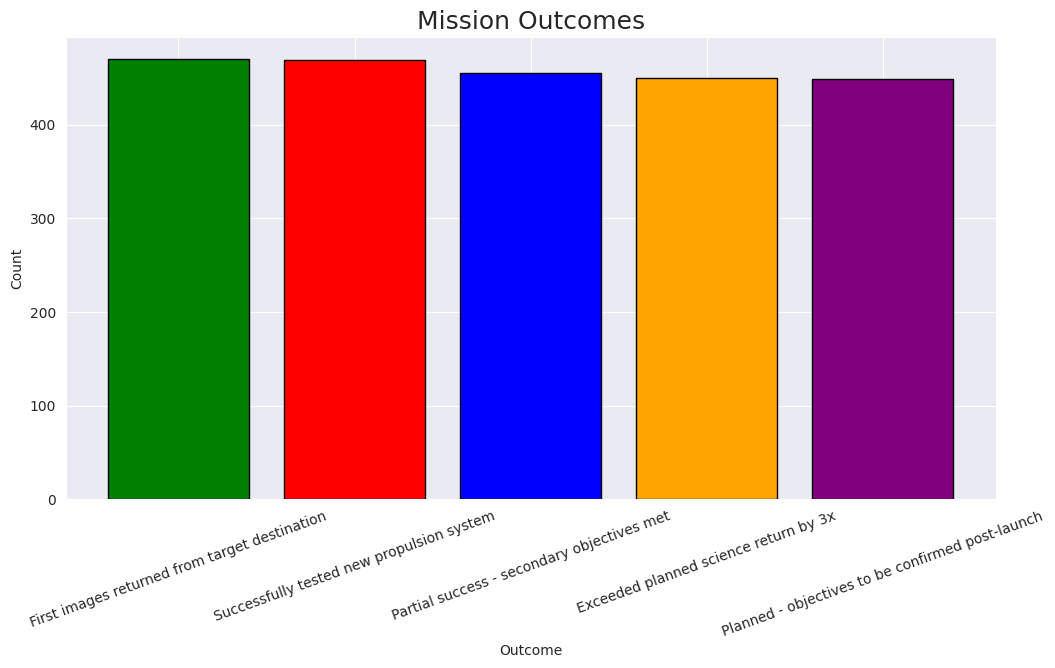

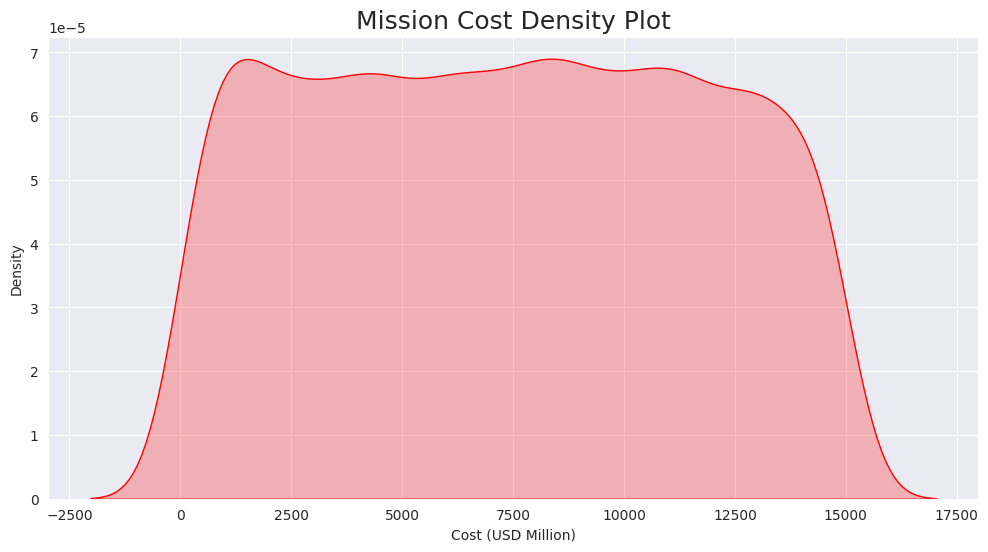


ALL VISUALIZATIONS COMPLETED SUCCESSFULLY


In [13]:
print("="*70)
print("DATASET SHAPE")
print("="*70)
print(df.shape)

print("\n" + "="*70)
print("COLUMN NAMES")
print("="*70)
print(df.columns)

print("\n" + "="*70)
print("FIRST 5 ROWS")
print("="*70)
print(df.head())

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
print(df.isnull().sum())

# =========================================================
# DATA CLEANING
# =========================================================

# -----------------------------
# Convert Date Columns
# -----------------------------
df['Launch_Date'] = pd.to_datetime(
    df['Launch_Date'],
    errors='coerce'
)

df['End_Date'] = pd.to_datetime(
    df['End_Date'],
    errors='coerce'
)

# -----------------------------
# Create Year and Month Columns
# -----------------------------
df['Launch_Year'] = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month_name()

# -----------------------------
# CLEAN DURATION COLUMN
# -----------------------------
df['Duration'] = pd.to_numeric(
    df['Duration'],
    errors='coerce'
)

df['Duration'] = df['Duration'].fillna(
    df['Duration'].median()
)

# -----------------------------
# CLEAN COST COLUMN
# -----------------------------
df['Cost_USD_Million'] = pd.to_numeric(
    df['Cost_USD_Million'],
    errors='coerce'
)

df['Cost_USD_Million'] = df['Cost_USD_Million'].fillna(
    df['Cost_USD_Million'].median()
)

# -----------------------------
# CLEAN CREW MEMBERS COLUMN
# -----------------------------
df['Crew_Members'] = df['Crew_Members'].astype(str)

# Extract numbers only
df['Crew_Members'] = df['Crew_Members'].str.extract('(\d+)')

# Convert to numeric
df['Crew_Members'] = pd.to_numeric(
    df['Crew_Members'],
    errors='coerce'
)

# Fill missing values
df['Crew_Members'] = df['Crew_Members'].fillna(0)

# =========================================================
# VISUALIZATION SETTINGS
# =========================================================
sns.set_style("darkgrid")

# =========================================================
# 1. MISSIONS BY COUNTRY
# =========================================================
plt.figure(figsize=(14,7))

country_counts = df['Country_Region'].value_counts().head(10)

colors = [
    'red','blue','green','purple','orange',
    'cyan','magenta','gold','brown','pink'
]

country_counts.plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title("Top 10 Countries by Missions", fontsize=18)
plt.xlabel("Country")
plt.ylabel("Mission Count")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 2. AGENCY TYPE DISTRIBUTION
# =========================================================
plt.figure(figsize=(10,8))

agency_counts = df['Agency_Type'].value_counts()

plt.pie(
    agency_counts,
    labels=agency_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3'),
    shadow=True,
    startangle=90
)

plt.title("Agency Type Distribution", fontsize=18)
plt.show()

# =========================================================
# 3. MISSION STATUS DISTRIBUTION
# =========================================================
plt.figure(figsize=(12,6))

sns.countplot(
    x='Status',
    data=df,
    palette='viridis'
)

plt.title("Mission Status Distribution", fontsize=18)
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# =========================================================
# 4. MISSIONS PER YEAR
# =========================================================
plt.figure(figsize=(15,6))

year_counts = df['Launch_Year'].value_counts().sort_index()

plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o',
    linewidth=3,
    color='darkblue'
)

plt.title("Missions Launched Per Year", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Mission Count")
plt.grid(True)
plt.show()

# =========================================================
# 5. TOP AGENCIES
# =========================================================
plt.figure(figsize=(14,7))

top_agencies = df['Agency'].value_counts().head(10)

sns.barplot(
    x=top_agencies.values,
    y=top_agencies.index,
    palette='coolwarm'
)

plt.title("Top 10 Agencies", fontsize=18)
plt.xlabel("Mission Count")
plt.ylabel("Agency")
plt.show()

# =========================================================
# 6. COST DISTRIBUTION
# =========================================================
plt.figure(figsize=(12,6))

sns.histplot(
    df['Cost_USD_Million'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Mission Cost Distribution", fontsize=18)
plt.xlabel("Cost (USD Million)")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 7. CREW MEMBERS DISTRIBUTION
# =========================================================
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['Crew_Members'],
    color='lightgreen'
)

plt.title("Crew Members Distribution", fontsize=18)
plt.xlabel("Crew Members")
plt.show()

# =========================================================
# 8. PROGRAM TYPE ANALYSIS
# =========================================================
plt.figure(figsize=(14,7))

program_counts = df['Program_Type'].value_counts().head(10)

program_counts.plot(
    kind='barh',
    color=sns.color_palette('magma', len(program_counts))
)

plt.title("Top Program Types", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Program Type")
plt.show()

# =========================================================
# 9. DESTINATION ANALYSIS
# =========================================================
plt.figure(figsize=(14,7))

destination_counts = df['Destination'].value_counts().head(10)

sns.barplot(
    x=destination_counts.index,
    y=destination_counts.values,
    palette='Spectral'
)

plt.title("Top Destinations", fontsize=18)
plt.xlabel("Destination")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 10. MISSION CATEGORY DISTRIBUTION
# =========================================================
plt.figure(figsize=(14,7))

sns.countplot(
    y='Mission_Category',
    data=df,
    palette='cubehelix',
    order=df['Mission_Category'].value_counts().index
)

plt.title("Mission Category Distribution", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Mission Category")
plt.show()

# =========================================================
# 11. CREW TYPE DISTRIBUTION
# =========================================================
plt.figure(figsize=(10,8))

crew_counts = df['Crew_Type'].value_counts()

plt.pie(
    crew_counts,
    labels=crew_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    shadow=True
)

plt.title("Crew Type Distribution", fontsize=18)
plt.show()

# =========================================================
# 12. TOP LAUNCH VEHICLES
# =========================================================
plt.figure(figsize=(15,7))

vehicle_counts = df['Launch_Vehicle'].value_counts().head(10)

sns.barplot(
    x=vehicle_counts.values,
    y=vehicle_counts.index,
    palette='rocket'
)

plt.title("Top Launch Vehicles", fontsize=18)
plt.xlabel("Mission Count")
plt.ylabel("Launch Vehicle")
plt.show()

# =========================================================
# 13. MONTHLY MISSION LAUNCHES
# =========================================================
plt.figure(figsize=(15,7))

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

sns.countplot(
    x='Launch_Month',
    data=df,
    order=month_order,
    palette='husl'
)

plt.title("Monthly Mission Launches", fontsize=18)
plt.xlabel("Month")
plt.ylabel("Mission Count")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 14. CORRELATION HEATMAP
# =========================================================
plt.figure(figsize=(10,6))

numeric_cols = [
    'Duration',
    'Crew_Members',
    'Cost_USD_Million'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=2
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# =========================================================
# 15. COST BY STATUS
# =========================================================
plt.figure(figsize=(14,7))

sns.boxplot(
    x='Status',
    y='Cost_USD_Million',
    data=df,
    palette='Set2'
)

plt.title("Mission Cost by Status", fontsize=18)
plt.xlabel("Status")
plt.ylabel("Cost (USD Million)")
plt.xticks(rotation=30)
plt.show()

# =========================================================
# 16. DURATION VS COST
# =========================================================
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='Duration',
    y='Cost_USD_Million',
    hue='Status',
    palette='bright',
    data=df,
    s=100
)

plt.title("Duration vs Cost", fontsize=18)
plt.xlabel("Duration")
plt.ylabel("Cost (USD Million)")
plt.show()

# =========================================================
# 17. PAIRPLOT
# =========================================================
sns.pairplot(
    df[['Duration','Crew_Members','Cost_USD_Million']],
    diag_kind='kde'
)

plt.show()

# =========================================================
# 18. TOP LAUNCH SITES
# =========================================================
plt.figure(figsize=(15,7))

site_counts = df['Launch_Site'].value_counts().head(10)

sns.barplot(
    x=site_counts.values,
    y=site_counts.index,
    palette='flare'
)

plt.title("Top Launch Sites", fontsize=18)
plt.xlabel("Mission Count")
plt.ylabel("Launch Site")
plt.show()

# =========================================================
# 19. MISSION OUTCOMES
# =========================================================
plt.figure(figsize=(12,6))

outcome_counts = df['Mission_Outcome_Detail'].value_counts().head(5)

plt.bar(
    outcome_counts.index,
    outcome_counts.values,
    color=['green','red','blue','orange','purple'],
    edgecolor='black'
)

plt.title("Mission Outcomes", fontsize=18)
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# =========================================================
# 20. KDE PLOT OF COST
# =========================================================
plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df['Cost_USD_Million'],
    fill=True,
    color='red'
)

plt.title("Mission Cost Density Plot", fontsize=18)
plt.xlabel("Cost (USD Million)")
plt.show()

# =========================================================
# FINAL MESSAGE
# =========================================================
print("\n" + "="*70)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY")
print("="*70)

DATASET SHAPE
(10500, 28)

FIRST 5 ROWS
  Mission_ID        Mission_Name Agency Country_Region Agency_Type  \
0   NA-00001          Explorer 1   NASA            USA  Government   
1   NA-00002           Pioneer 1   NASA            USA  Government   
2   NA-00003  Mercury-Redstone 1   NASA            USA  Government   
3   NA-00004           Freedom 7   NASA            USA  Government   
4   NA-00005        Friendship 7   NASA            USA  Government   

        Program_Type   Mission_Category   Sub_Category Launch_Date   End_Date  \
0    Technology Demo            Mercury        Orbiter  1976-01-12 1987-02-18   
1  Human Spaceflight             Saturn          Flyby  1977-05-01 1984-07-15   
2    Sounding Rocket  Earth Observation  Climate Study  1966-01-13 1969-12-13   
3          Satellite            Mercury          Flyby  1987-07-06 1989-03-19   
4         Commercial          Telescope          Radio  2012-09-09        NaT   

   ...                                         Objec

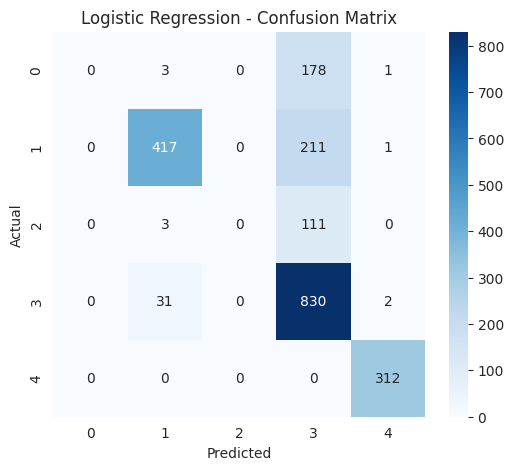


Decision Tree

Accuracy : 0.6367

CLASSIFICATION REPORT
--------------------------------------------------
                 precision    recall  f1-score   support

         Failed       0.13      0.13      0.13       182
        Ongoing       0.71      0.72      0.72       629
Partial Success       0.09      0.10      0.10       114
        Success       0.62      0.62      0.62       863
       Upcoming       1.00      1.00      1.00       312

       accuracy                           0.64      2100
      macro avg       0.51      0.51      0.51      2100
   weighted avg       0.64      0.64      0.64      2100



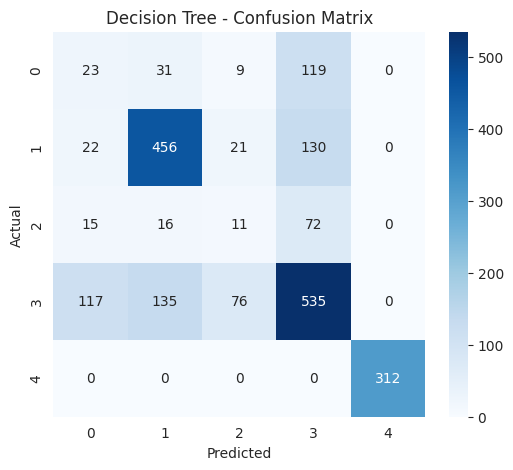


Random Forest

Accuracy : 0.7571

CLASSIFICATION REPORT
--------------------------------------------------
                 precision    recall  f1-score   support

         Failed       0.00      0.00      0.00       182
        Ongoing       1.00      0.66      0.80       629
Partial Success       0.00      0.00      0.00       114
        Success       0.63      1.00      0.77       863
       Upcoming       1.00      1.00      1.00       312

       accuracy                           0.76      2100
      macro avg       0.53      0.53      0.51      2100
   weighted avg       0.71      0.76      0.70      2100



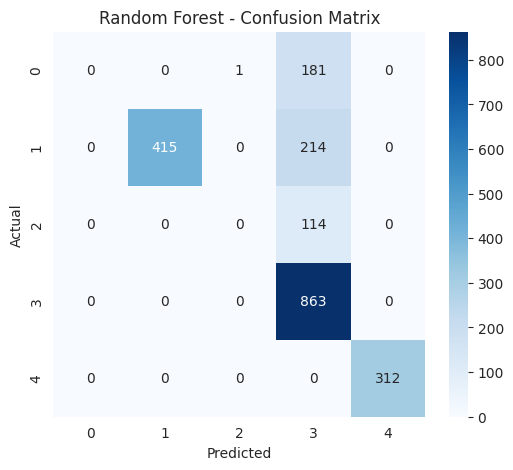


KNN

Accuracy : 0.5000

CLASSIFICATION REPORT
--------------------------------------------------
                 precision    recall  f1-score   support

         Failed       0.17      0.09      0.12       182
        Ongoing       0.43      0.60      0.50       629
Partial Success       0.08      0.03      0.04       114
        Success       0.60      0.64      0.62       863
       Upcoming       0.59      0.33      0.42       312

       accuracy                           0.50      2100
      macro avg       0.37      0.34      0.34      2100
   weighted avg       0.48      0.50      0.48      2100



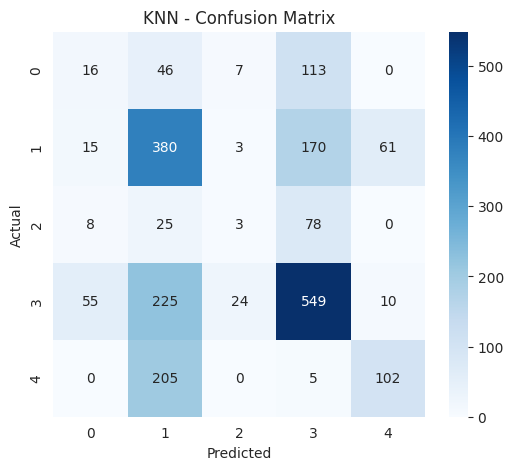


SVM

Accuracy : 0.4110

CLASSIFICATION REPORT
--------------------------------------------------
                 precision    recall  f1-score   support

         Failed       0.00      0.00      0.00       182
        Ongoing       0.00      0.00      0.00       629
Partial Success       0.00      0.00      0.00       114
        Success       0.41      1.00      0.58       863
       Upcoming       0.00      0.00      0.00       312

       accuracy                           0.41      2100
      macro avg       0.08      0.20      0.12      2100
   weighted avg       0.17      0.41      0.24      2100



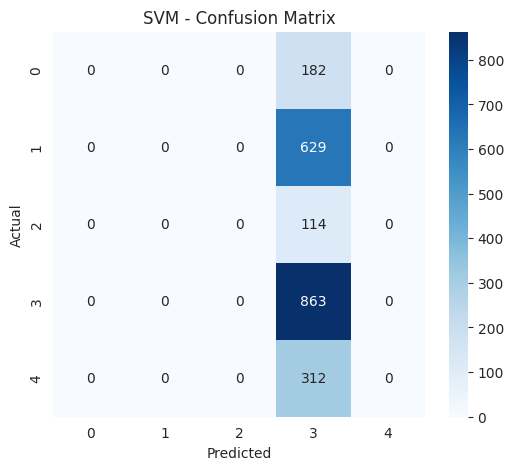


FINAL MODEL ACCURACY COMPARISON
                 Model  Accuracy
2        Random Forest  0.757143
0  Logistic Regression  0.742381
1        Decision Tree  0.636667
3                  KNN  0.500000
4                  SVM  0.410952


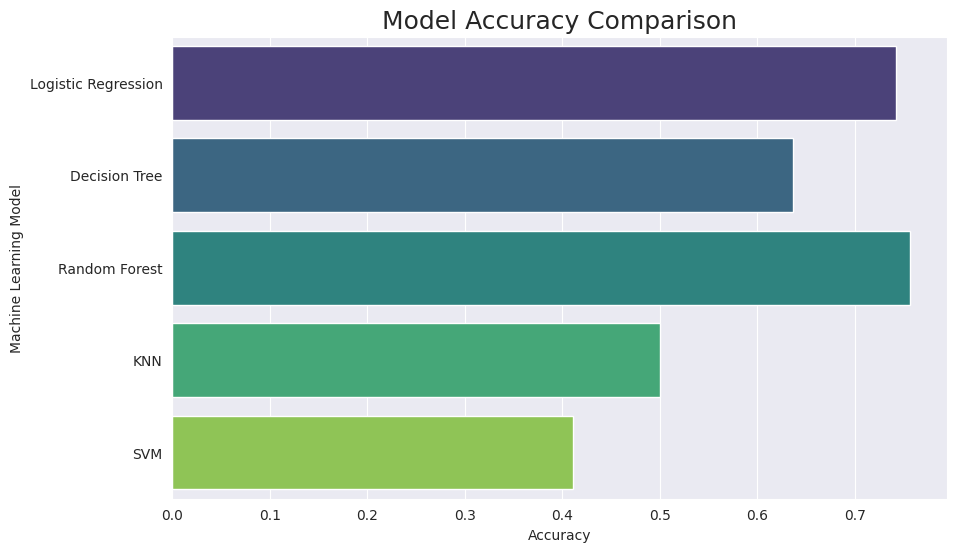


BEST MODEL
Model Name : Random Forest
Accuracy   : 0.7571

MACHINE LEARNING PROJECT COMPLETED


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
# ============================================================
# DISPLAY BASIC INFO
# ============================================================
print("="*70)
print("DATASET SHAPE")
print("="*70)
print(df.shape)

print("\n" + "="*70)
print("FIRST 5 ROWS")
print("="*70)
print(df.head())

print("\n" + "="*70)
print("COLUMN NAMES")
print("="*70)
print(df.columns)

# ============================================================
# TARGET COLUMN
# ============================================================
# We use Status as target variable

print("\n" + "="*70)
print("TARGET COLUMN DISTRIBUTION")
print("="*70)
print(df['Status'].value_counts())

# ============================================================
# DATA CLEANING
# ============================================================

# Convert date columns
df['Launch_Date'] = pd.to_datetime(
    df['Launch_Date'],
    errors='coerce'
)

df['End_Date'] = pd.to_datetime(
    df['End_Date'],
    errors='coerce'
)

# Extract year/month/day
df['Launch_Year'] = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month
df['Launch_Day'] = df['Launch_Date'].dt.day

# ============================================================
# CLEAN NUMERIC COLUMNS
# ============================================================

# Duration
df['Duration'] = pd.to_numeric(
    df['Duration'],
    errors='coerce'
)

# Cost
df['Cost_USD_Million'] = pd.to_numeric(
    df['Cost_USD_Million'],
    errors='coerce'
)

# Crew Members
df['Crew_Members'] = (
    df['Crew_Members']
    .astype(str)
    .str.extract('(\d+)')[0]
)

df['Crew_Members'] = pd.to_numeric(
    df['Crew_Members'],
    errors='coerce'
)

# ============================================================
# DROP UNUSED COLUMNS
# ============================================================

drop_columns = [
    'Mission_ID',
    'Mission_Name',
    'Launch_Date',
    'End_Date',
    'Reference_URL',
    'Objective',
    'Key_Achievement',
    'Failure_Reason',
    'Mission_Outcome_Detail'
]

df = df.drop(columns=drop_columns, errors='ignore')

# ============================================================
# HANDLE MISSING TARGET VALUES
# ============================================================
df = df.dropna(subset=['Status'])

# ============================================================
# DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop('Status', axis=1)
y = df['Status']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# No Data Leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "="*70)
print("TRAIN TEST SPLIT")
print("="*70)
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print("\n" + "="*70)
print("CATEGORICAL COLUMNS")
print("="*70)
print(categorical_cols)

print("\n" + "="*70)
print("NUMERICAL COLUMNS")
print("="*70)
print(numerical_cols)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# ============================================================
# TRAINING + EVALUATION
# ============================================================

results = []

for model_name, model in models.items():

    print("\n" + "="*80)
    print(f"{model_name}")
    print("="*80)

    # Create full pipeline
    clf = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # ========================================================
    # TRAIN MODEL
    # ========================================================
    clf.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================
    y_pred = clf.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================
    print("\nCLASSIFICATION REPORT")
    print("-"*50)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    # Binary classification only
    if len(y.unique()) == 2:

        # Probability prediction
        y_prob = clf.predict_proba(X_test)[:,1]

        # Convert labels to numeric
        y_test_numeric = pd.factorize(y_test)[0]

        # ROC values
        fpr, tpr, thresholds = roc_curve(
            y_test_numeric,
            y_prob
        )

        # AUC Score
        auc_score = roc_auc_score(
            y_test_numeric,
            y_prob
        )

        # Plot ROC Curve
        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            label=f"AUC = {auc_score:.4f}",
            linewidth=3
        )

        plt.plot(
            [0,1],
            [0,1],
            linestyle='--'
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"{model_name} - ROC Curve")

        plt.legend()

        plt.show()

        print(f"ROC AUC Score : {auc_score:.4f}")

    # Save Results
    results.append([model_name, accuracy])

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

print("\n" + "="*80)
print("FINAL MODEL ACCURACY COMPARISON")
print("="*80)

print(results_df.sort_values(
    by='Accuracy',
    ascending=False
))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy")
plt.ylabel("Machine Learning Model")

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n" + "="*80)
print("BEST MODEL")
print("="*80)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print("\n" + "="*80)
print("MACHINE LEARNING PROJECT COMPLETED")
print("="*80)

## thank you...pls upvote!!!!!!!!!!